In [27]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

In [158]:
# units: mhz, W


power_data = {
    "scalar": {
        50: 0.076,
        75: 0.085,
        100: 0.093,
        125: 0.101,
        150: 0.111,
        200: 0.127,
        250: 0.144,
        375: 0.188,
        500: 0.227,
        600: 0.259,
    },
    "vector": {
        50: 0.075,
        75: 0.084,
        100: 0.092,
        125: 0.101,
        150: 0.109,
        200: 0.125,
        250: 0.142,
        375: 0.183,
        500: 0.224,
        600: 0.260,
    }
}

In [197]:
def trajectory_passed(data,
                      z_threshold=0.05,
                      xy_limit=10.0,
                      z_index=2):
    """
    Given a structured-array `data` with fields:
      - data['state'] shape (N,12)
      - data['tx'], data['ty'], data['tz'] shape (N,)
    returns True if:
      1) reconstructed Z = state[:,z_index] + tz never dips below z_threshold
      2) reconstructed X,Y = state[:,0:2] + [tx,ty] always lie inside
         [-xy_limit, xy_limit] × [-xy_limit, xy_limit]
    """
    # world-frame Z
    rel_z    = data['state'][:, z_index]
    actual_z = rel_z + data['tz']
    if np.any(actual_z < z_threshold):
        return False

    # world-frame XY
    rel_xy    = data['state'][:, :2]
    target_xy = np.stack([data['tx'], data['ty']], axis=1)
    actual_xy = rel_xy + target_xy
    if np.any(np.abs(actual_xy) > xy_limit):
        return False

    return True

def trajectory_passed_file(path, **kwargs):
    """
    Loads the .npy at `path` and applies trajectory_passed.
    All kwargs (z_threshold, xy_limit, z_index) are passed through.
    """
    data = np.load(path, allow_pickle=False)
    return trajectory_passed(data, **kwargs)


In [169]:
import os
import numpy as np

def evaluate_logs(directory, z_index=2, threshold=0.1):
    """
    Scans all .npy files in `directory`, reconstructing each step's
    world-frame Z height as (relative_z + target_z), and checks against
    `threshold`. Returns two lists: (passed_files, failed_files).
    """
    passed = []
    failed = []
    for fn in os.listdir(directory):
        if not fn.endswith('.npy'):
            continue
        path = os.path.join(directory, fn)
        data = np.load(path, allow_pickle=False)

        # relative Z from state
        rel_z    = data['state'][:, z_index]
        # target Z per step
        target_z = data['tz']
        # reconstructed world Z
        actual_z = rel_z + target_z

        if np.any(actual_z < threshold):
            failed.append(fn)
        else:
            passed.append(fn)

    return passed, failed


In [16]:
# Example usage:
log_dir = "data_rvv_handopt_20mhz_0.2_scale"  # <-- change to your log folder
log_dir = "data_scalar_20mhz_0.2_scale"  # <-- change to your log folder
passed, failed = evaluate_logs(log_dir)

print("✅ Passed:")
for f in passed:
    print("   ", f)
print("\n❌ Failed:")
for f in failed:
    print("   ", f)


✅ Passed:
    easy_11.npy
    easy_19.npy
    medium_9.npy
    easy_13.npy
    easy_10.npy
    medium_20.npy
    easy_17.npy
    medium_1.npy
    easy_18.npy
    easy_2.npy
    hard_1.npy
    easy_3.npy
    easy_12.npy
    easy_6.npy
    easy_8.npy
    medium_5.npy
    easy_15.npy
    medium_14.npy
    medium_15.npy
    easy_1.npy
    medium_8.npy
    medium_19.npy
    easy_5.npy
    easy_7.npy
    medium_17.npy
    easy_14.npy
    medium_16.npy
    medium_7.npy
    easy_9.npy
    medium_10.npy
    easy_4.npy
    medium_3.npy
    easy_16.npy
    easy_20.npy
    medium_4.npy
    medium_2.npy
    medium_12.npy

❌ Failed:
    hard_15.npy
    hard_7.npy
    hard_6.npy
    hard_12.npy
    medium_6.npy
    medium_18.npy
    hard_9.npy
    hard_17.npy
    hard_10.npy
    hard_19.npy
    hard_14.npy
    hard_16.npy
    hard_20.npy
    hard_18.npy
    medium_11.npy
    hard_5.npy
    hard_8.npy
    hard_11.npy
    hard_4.npy
    hard_13.npy
    hard_3.npy
    medium_13.npy
    hard_2.npy


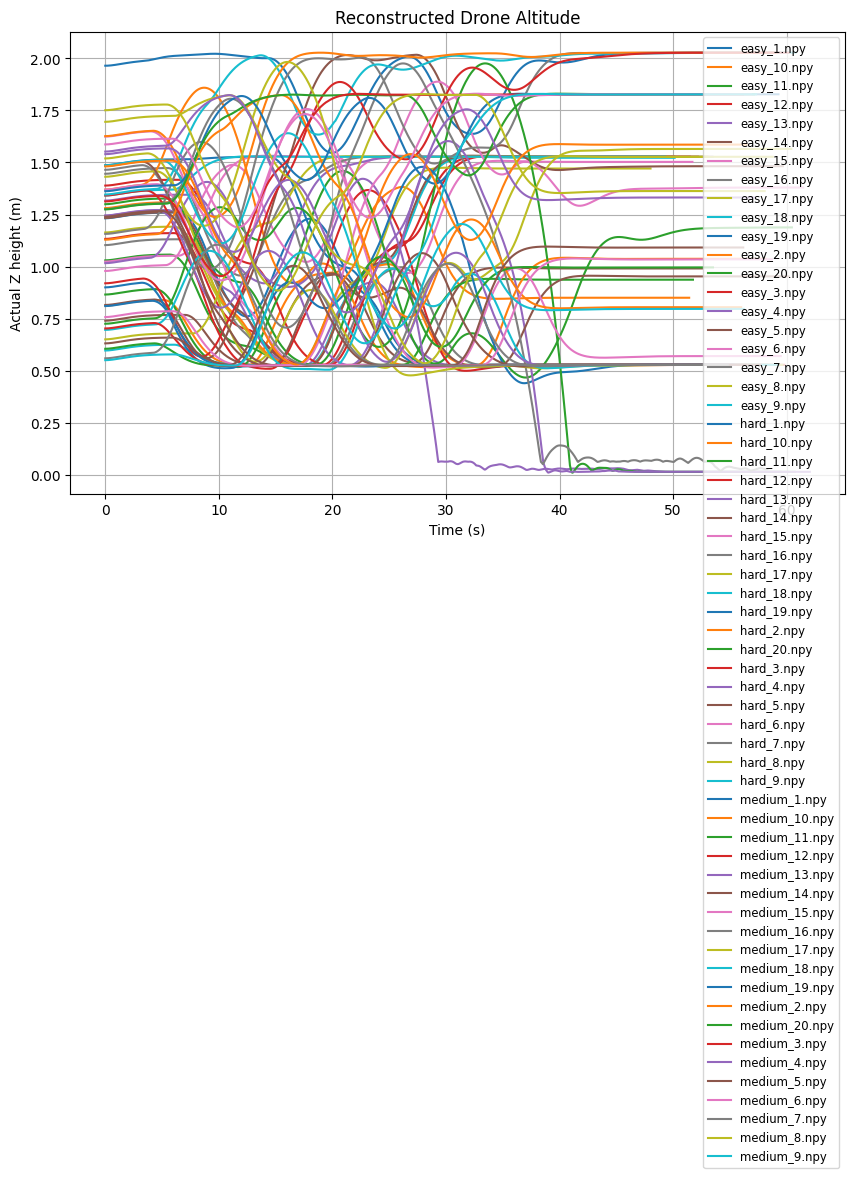

In [90]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_actual_z(log_dir, z_idx=2):
    """
    For each .npy in log_dir, reconstruct actual world‐frame Z as:
        actual_z = logged_rel_z + logged_target_z
    and plot actual_z vs time (using wall_time).
    """
    plt.figure(figsize=(10,6))
    for fn in sorted(os.listdir(log_dir)):
        if not fn.endswith('.npy'):
            continue
        path = os.path.join(log_dir, fn)
        data = np.load(path, allow_pickle=False)
        # relative z from state
        rel_z    = data['state'][:, z_idx]
        # target z per step
        target_z = data['tz']
        # reconstruct world z
        actual_z = rel_z + target_z

        # time axis from wall_time
        t0    = data['wall_time'][0]
        times = data['wall_time'] - t0

        plt.plot(times, actual_z, label=fn)

    plt.xlabel("Time (s)")
    plt.ylabel("Actual Z height (m)")
    plt.title("Reconstructed Drone Altitude")
    plt.legend(fontsize="small", loc="best")
    plt.grid(True)
    plt.show()

# Example usage:
# plot_actual_z("data_rvv_handopt_20mhz_0.2_scale")  # replace with your log directory
plot_actual_z("data_ideal")


In [170]:
def summarize_directory(dir_path):
    """
    For a single directory of .npy logs, compute pass% per difficulty,
    where “pass” is determined by `trajectory_passed_file(path)`.
    Difficulty is inferred from filename prefix: 'easy', 'medium', 'hard'.
    Returns a dict:
      {
        'easy':   {'percent_passed':…, 'passed':…, 'total':…},
        'medium': {...},
        'hard':   {...}
      }
    """
    stats = {
        'easy':   {'passed': 0, 'total': 0},
        'medium': {'passed': 0, 'total': 0},
        'hard':   {'passed': 0, 'total': 0},
    }

    for fn in os.listdir(dir_path):
        if not fn.endswith('.npy'):
            continue

        # infer difficulty
        difficulty = None
        for diff in stats:
            if fn.startswith(diff + '_'):
                difficulty = diff
                break
        if difficulty is None:
            continue

        path = os.path.join(dir_path, fn)
        # use the helper; relies on its own default thresholds
        passed = trajectory_passed_file(path)

        stats[difficulty]['total'] += 1
        if passed:
            stats[difficulty]['passed'] += 1

    # build summary
    summary = {}
    for diff, vals in stats.items():
        total  = vals['total']
        passed = vals['passed']
        pct = 100.0 * passed / total if total > 0 else np.nan
        summary[diff] = {
            'percent_passed': pct,
            'passed': passed,
            'total': total
        }
    return summary


In [95]:
def compute_avg_power(directory,
                      hover_rpm=14000,
                      hover_power=1.25,
                      crash_threshold=0.1,
                      max_rpm=21702):
    """
    Scans all .npy logs in `directory`, groups them by difficulty
    (filename prefix 'easy_', etc.), excludes any log where the reconstructed
    Z ever drops below `crash_threshold`, clips commanded RPMs to `max_rpm`,
    and computes the average *total* actuator power (sum of all four props)
    in watts via:
        P_motor(rpm) = hover_power * (rpm / hover_rpm)**3
        P_total   = sum over 4 motors
    Returns a dict: { 'easy': avg_P, 'medium': avg_P, 'hard': avg_P }.
    """
    results = {}
    for diff in ('easy', 'medium', 'hard'):
        sumP  = 0.0
        count = 0
        prefix = diff + '_'
        for fn in os.listdir(directory):
            if not fn.endswith('.npy') or not fn.startswith(prefix):
                continue
            data = np.load(os.path.join(directory, fn), allow_pickle=False)

            # reconstruct world‐frame Z
            rel_z    = data['state'][:, 2]
            target_z = data['tz']
            actual_z = rel_z + target_z

            # skip crashes
            if np.any(actual_z < crash_threshold):
                continue

            # clip RPM and compute per‐motor power
            rpm = data['rpm'].astype(np.float64)
            rpm_clipped = np.clip(rpm, 0.0, max_rpm)
            P = hover_power * (rpm_clipped / hover_rpm) ** 3  # shape (n_steps,4)

            # **sum** across 4 motors each timestep
            P_t = P.sum(axis=1)  # shape (n_steps,)

            sumP  += P_t.sum()
            count += P_t.size

        results[diff] = (sumP / count) if count > 0 else np.nan

    return results

In [96]:
def plot_xy_scatter_with_failures(directories,
                                  z_index=2,
                                  crash_threshold=0.1):
    """
    For each directory in `directories`, load all .npy logs and plot the
    reconstructed world‐frame XY trajectories, coloring by difficulty:
       - easy:   green (dark green if failed)
       - medium: blue  (dark blue  if failed)
       - hard:   red   (dark red   if failed)
    Layers: hard on bottom, then medium, then easy on top.
    """
    # base & failure colors
    colors       = {'easy':'green',  'medium':'blue',  'hard':'red'}
    colors_fail  = {'easy':'darkgreen','medium':'darkblue','hard':'darkred'}
    # draw order: hard→medium→easy
    order = ['hard','medium','easy']

    for log_dir in directories:
        plt.figure(figsize=(8,8))

        for zord, diff in enumerate(order, start=1):
            prefix = diff + '_'
            base_c  = colors[diff]
            fail_c  = colors_fail[diff]

            for fn in sorted(os.listdir(log_dir)):
                if not fn.endswith('.npy') or not fn.startswith(prefix):
                    continue

                data = np.load(os.path.join(log_dir, fn), allow_pickle=False)

                # reconstruct XY
                rel_xy    = data['state'][:, :2]
                target_xy = np.stack([data['tx'], data['ty']], axis=1)
                actual_xy = rel_xy + target_xy

                # reconstruct Z and check crash
                rel_z     = data['state'][:, z_index]
                actual_z  = rel_z + data['tz']
                failed    = np.any(actual_z < crash_threshold)

                # choose color
                c = fail_c if failed else base_c

                plt.scatter(actual_xy[:,0],
                            actual_xy[:,1],
                            s=2,
                            c=c,
                            alpha=0.6,
                            zorder=zord)

        # custom legend
        handles, labels = [], []
        for diff in order[::-1]:  # easy, medium, hard
            handles.append(plt.Line2D([0],[0],
                            marker='o', color='w',
                            markerfacecolor=colors[diff],
                            markersize=6))
            labels.append(diff.capitalize())
        plt.legend(handles, labels, title="Difficulty")

        plt.title(f"XY Trajectories: {log_dir}")
        plt.xlabel("X (m)")
        plt.ylabel("Y (m)")
        plt.axis('equal')
        plt.grid(True)
        plt.show()

In [179]:
def compute_avg_power(directory,
                      hover_rpm=14000,
                      hover_power=1.25,
                      max_rpm=21702):
    """
    Loads all .npy logs in `directory`, groups by difficulty
    ('easy_', 'medium_', 'hard_'), excludes any log for which
    trajectory_passed_file(path) is False, clips commanded RPMs to `max_rpm`,
    sums the per‐motor power P = hover_power * (rpm/hover_rpm)**3,
    and returns a dict { 'easy':…, 'medium':…, 'hard':… } of average total power.
    """
    results = {}
    for diff in ('easy','medium','hard'):
        sumP  = 0.0
        count = 0
        prefix = diff + '_'
        for fn in os.listdir(directory):
            if not fn.endswith('.npy') or not fn.startswith(prefix):
                continue
            path = os.path.join(directory, fn)
            # skip any failed trajectories
            if not trajectory_passed_file(path):
                continue

            data = np.load(path, allow_pickle=False)
            rpm = data['rpm'].astype(np.float64)
            rpm_clipped = np.clip(rpm, 0.0, max_rpm)
            # per‐motor power
            P = hover_power * (rpm_clipped / hover_rpm)**3  # (steps,4)
            # total per‐step
            P_t = P.sum(axis=1)
            sumP  += P_t.sum()
            count += P_t.size

        results[diff] = (sumP / count) if count > 0 else np.nan

    return results

def plot_power_vs_freq(directories,
                       power_data=None,
                       hover_rpm=14000,
                       hover_power=1.25,
                       crash_threshold=0.1,
                       max_rpm=21702):
    """
    Given a list of directories like
      'data_ideal',
      'data_scalar_20mhz_0.2_scale', 'data_rvv_handopt_30mhz_0.2_scale', ...
    plots:
      - horizontal dotted lines at the 'ideal' avg power for each difficulty
      - curves of avg power vs (mhz/scale) for scalar (dashed) and vector (solid)
        with easy=green, medium=blue, hard=red.
    """
    # find and compute ideal baseline
    ideal_dirs = [d for d in directories if 'ideal' in d]
    if not ideal_dirs:
        raise ValueError("No 'ideal' directory found in input list")
    ideal_avg = compute_avg_power(ideal_dirs[0],
                                  hover_rpm, hover_power,
                                  max_rpm)

    # parse scalar/vector directories
    results = {'scalar': {'easy':[], 'medium':[], 'hard':[]},
               'vector': {'easy':[], 'medium':[], 'hard':[]}}

    for d in directories:
        if 'ideal' in d:
            continue
        # detect implementation
        if 'scalar' in d:
            meas = 'scalar'
        elif 'rvv_handopt' in d:
            meas = 'vector'
        else:
            continue

        # extract mhz and scale from dirname
        m = re.search(r'_(\d+(?:\.\d+)?)mhz_', d)
        s = re.search(r'_(\d+(?:\.\d+)?)_scale', d)
        if not m or not s:
            continue
        mhz   = float(m.group(1))
        scale = float(s.group(1))
        freq  = mhz / scale

        avgP = compute_avg_power(d,
                                 hover_rpm, hover_power,
                                 max_rpm)
        if power_data is None:
            for diff in ('easy','medium','hard'):
                results[meas][diff].append((freq, avgP[diff]))
        else:
            for diff in ('easy','medium','hard'):
                results[meas][diff].append((freq, avgP[diff] + power_data[meas][freq]))


    # prepare plot
    colors = {'easy':'green','medium':'blue','hard':'red'}
    plt.figure(figsize=(8,6))

    # plot ideal baselines
    for diff, col in colors.items():
        plt.axhline(ideal_avg[diff],
                    color=col,
                    linestyle=':',
                    label=f"{diff.capitalize()} ideal")

    # plot scalar/vector curves
    for diff, col in colors.items():
        # scalar: dashed
        data_s = sorted(results['scalar'][diff], key=lambda x:x[0])
        if data_s:
            xs, ys = zip(*data_s)
            plt.plot(xs, ys,
                     linestyle='--',
                     color=col,
                     label=f"{diff.capitalize()} scalar")
        # vector: solid
        data_v = sorted(results['vector'][diff], key=lambda x:x[0])
        if data_v:
            xv, yv = zip(*data_v)
            plt.plot(xv, yv,
                     linestyle='-',
                     color=col,
                     label=f"{diff.capitalize()} vector")

    plt.xlabel("Effective Frequency (MHz)")
    plt.ylabel("Average Power (W)")
    plt.title("Average Power vs Frequency")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()




In [190]:
def plot_power_bar_chart(directories,
                         power_data,
                         hover_rpm=14000,
                         hover_power=1.25,
                         crash_threshold=0.05,
                         max_rpm=21702):
    """
    Bar‐chart of total power (actuators + CPU) vs effective frequency.
    Stacked bars: bottom=actuator, top=CPU.
    Creates one subplot per difficulty (easy, medium, hard).
    """
    # parse data
    # for each meas in scalar/vector, diff in easy/medium/hard, collect (freq, act, cpu)
    data_store = {
        'scalar': { 'easy':[], 'medium':[], 'hard':[] },
        'vector': { 'easy':[], 'medium':[], 'hard':[] },
    }

    for d in directories:
        if 'ideal' in d:
            continue

        if 'scalar' in d:
            meas = 'scalar'
        elif 'rvv_handopt' in d:
            meas = 'vector'
        else:
            continue

        m = re.search(r'_(\d+(?:\.\d+)?)mhz_', d)
        s = re.search(r'_(\d+(?:\.\d+)?)_scale', d)
        if not m or not s:
            continue
        mhz = float(m.group(1))
        scale = float(s.group(1))
        freq = mhz / scale
        cpu_p = power_data.get(meas, {}).get(freq)
        if cpu_p is None:
            continue

        ap = compute_avg_power(d,
                                        hover_rpm, hover_power,
                                        max_rpm)
        for diff in ('easy','medium','hard'):
            act_p = ap[diff]
            if np.isnan(act_p):
                continue
            data_store[meas][diff].append((freq, act_p, cpu_p))

    # plot
    difficulties = ['easy','medium','hard']
    colors = {'easy':'green','medium':'blue','hard':'red'}
    fig, axes = plt.subplots(3,1, figsize=(8,12), sharex=True)

    for i, diff in enumerate(difficulties):
        ax = axes[i]
        ax.set_title(f"{diff.capitalize()} Trajectories")
        ax.set_ylabel("Power (W)")
        # collect freqs
        scalar_data = sorted(data_store['scalar'][diff], key=lambda x:x[0])
        vector_data = sorted(data_store['vector'][diff], key=lambda x:x[0])
        # x positions
        freqs = sorted({f for f,_,_ in scalar_data + vector_data})
        x = np.arange(len(freqs))
        width = 0.35

        # map freq→(act,cpu)
        sd_map = {f:(a,c) for f,a,c in scalar_data}
        vd_map = {f:(a,c) for f,a,c in vector_data}

        # bars
        # scalar: left of center
        act_s = [sd_map.get(f,(np.nan,0))[0] for f in freqs]
        cpu_s = [sd_map.get(f,(0,np.nan))[1] for f in freqs]
        bar_s_act = ax.bar(x - width/2, act_s, width,
                           color=colors[diff], alpha=0.6,
                           label='scalar (actuators)')
        ax.bar(x - width/2, cpu_s, width,
               bottom=act_s, color=colors[diff], alpha=1.0,
               label='scalar (CPU)', hatch='//')

        # vector: right of center
        act_v = [vd_map.get(f,(np.nan,0))[0] for f in freqs]
        cpu_v = [vd_map.get(f,(0,np.nan))[1] for f in freqs]
        ax.bar(x + width/2, act_v, width,
               color=colors[diff], alpha=0.3,
               label='vector (actuators)')
        ax.bar(x + width/2, cpu_v, width,
               bottom=act_v, color=colors[diff], alpha=0.7,
               label='vector (CPU)', hatch='\\\\')

        ax.set_xticks(x)
        ax.set_xticklabels([f"{f:.0f}" for f in freqs])
        ax.grid(True)

    axes[-1].set_xlabel("Effective Frequency (MHz)")
    # consolidate legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=2)
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()

In [208]:

def plot_power_with_compute_gap(directories,
                                power_data,
                                hover_rpm=14000,
                                hover_power=1.25,
                                max_rpm=21702):
    """
    Line plot of total (actuator+CPU) power vs effective frequency, shaded
    down to the actuator-only line, with only total and ideal in legend.
    Legend is a single column to the right, grouped by difficulty.
    """
    # --- compute ideal actuator-only baselines ---
    ideal_dirs = [d for d in directories if 'ideal' in d]
    if not ideal_dirs:
        raise ValueError("No 'ideal' directory found")
    ideal_avg = compute_avg_power(ideal_dirs[0],
                                  hover_rpm, hover_power, max_rpm)

    # --- collect data ---
    results = {'scalar': {'easy':[], 'medium':[], 'hard':[]},
               'vector': {'easy':[], 'medium':[], 'hard':[]}}
    mhz_re   = re.compile(r'_(\d+(?:\.\d+)?)mhz_')
    scale_re = re.compile(r'_(\d+(?:\.\d+)?)_scale')

    for d in directories:
        if 'ideal' in d:
            continue
        if 'scalar' in d:
            meas = 'scalar'
        elif 'rvv_handopt' in d:
            meas = 'vector'
        else:
            continue

        m = mhz_re.search(d)
        s = scale_re.search(d)
        if not m or not s:
            continue
        mhz   = float(m.group(1))
        scale = float(s.group(1))
        freq  = mhz / scale

        cpu_map = power_data.get(meas, {})
        cpu_p   = cpu_map.get(freq)
        if cpu_p is None:
            continue

        ap = compute_avg_power(d, hover_rpm, hover_power, max_rpm)
        for diff in ('easy','medium','hard'):
            act_p = ap[diff]
            if np.isnan(act_p):
                continue
            total_p = act_p + cpu_p
            results[meas][diff].append((freq, act_p, total_p))

    # --- plotting ---
    colors = {'easy':'green','medium':'blue','hard':'red'}
    plt.figure(figsize=(8,6))

    # ideal baselines (will be in legend)
    for diff, col in colors.items():
        plt.axhline(ideal_avg[diff],
                    color=col,
                    linestyle=':',
                    label=f"{diff.capitalize()} ideal")

    # plot total lines and shade gaps
    for diff, col in colors.items():
        for meas, ls in [('scalar','--'), ('vector','-')]:
            data = sorted(results[meas][diff], key=lambda x: x[0])
            if not data:
                continue
            freqs, P_act, P_tot = zip(*data)
            # shade gap
            plt.fill_between(freqs, P_act, P_tot,
                             color=col, alpha=0.2, edgecolor='none')
            # plot total (only these in legend besides ideals)
            plt.plot(freqs, P_tot,
                     linestyle=ls,
                     color=col,
                     linewidth=2,
                     label=f"{diff.capitalize()} {meas} total")

    plt.xlabel("Effective Frequency (MHz)")
    plt.ylabel("Power (W)")
    plt.title("Total Power vs Frequency (shaded gap, totals + ideal)")
    plt.grid(True)

    # build grouped legend: one column on the right
    ax = plt.gca()
    handles, labels = ax.get_legend_handles_labels()
    ordered = []
    for diff in ('easy','medium','hard'):
        for suffix in ('ideal', 'scalar total', 'vector total'):
            name = f"{diff.capitalize()} {suffix}"
            if name in labels:
                idx = labels.index(name)
                ordered.append((handles[idx], labels[idx]))
    h, l = zip(*ordered)
    ax.legend(h, l,
              loc='center left',
              bbox_to_anchor=(1.02, 0.5),
              ncol=1,
              frameon=False)

    plt.tight_layout(rect=[0,0,0.75,1])
    plt.show()

In [156]:


def plot_total_power_vs_freq(directories,
                             power_data,
                             hover_rpm=14000,
                             hover_power=1.25,
                             crash_threshold=0.10,
                             max_rpm=21702):
    """
    Plots total power (actuator + CPU) vs effective frequency (MHz).
    - directories: list of folder names
    - power_data: dict mapping
        {
          'scalar': { freq_mhz: cpu_power_w, ... },
          'rvv_handopt': { freq_mhz: cpu_power_w, ... }
        }
    - other params as before
    """
    # parse and collect
    results = {
        'scalar': { 'easy':[], 'medium':[], 'hard':[] },
        'vector': { 'easy':[], 'medium':[], 'hard':[] },
    }

    for d in directories:
        if 'ideal' in d:
            continue

        # determine implementation
        if 'scalar' in d:
            meas = 'scalar'
        elif 'rvv_handopt' in d:
            meas = 'vector'
        else:
            continue

        # extract MHz and scale
        m = re.search(r'_(\d+(?:\.\d+)?)mhz_', d)
        s = re.search(r'_(\d+(?:\.\d+)?)_scale', d)
        if not m or not s:
            continue
        mhz   = float(m.group(1))
        scale = float(s.group(1))
        freq  = mhz / scale

        # lookup CPU power
        cpu_map = power_data.get(meas, {})
        cpu_p = cpu_map.get(freq)
        if cpu_p is None:
            continue

        # actuator power
        ap = compute_avg_power(
            d, hover_rpm, hover_power, crash_threshold, max_rpm
        )

        for diff in ('easy','medium','hard'):
            act_p = ap[diff]
            if np.isnan(act_p):
                continue
            total_p = act_p + cpu_p
            results[meas][diff].append((freq, total_p))

    # plot
    colors = {'easy':'green','medium':'blue','hard':'red'}
    plt.figure(figsize=(8,6))

    for diff in ('easy','medium','hard'):
        col = colors[diff]

        # scalar dashed
        data_s = sorted(results['scalar'][diff], key=lambda x:x[0])
        if data_s:
            xs, ys = zip(*data_s)
            plt.plot(xs, ys, linestyle='--', color=col,
                     label=f"{diff.capitalize()} scalar")

        # vector solid
        data_v = sorted(results['vector'][diff], key=lambda x:x[0])
        if data_v:
            xv, yv = zip(*data_v)
            plt.plot(xv, yv, linestyle='-', color=col,
                     label=f"{diff.capitalize()} vector")

    plt.xlabel("Effective Frequency (MHz)")
    plt.ylabel("Total Power (W) = Actuators + CPU")
    plt.title("Total Power vs Frequency by Difficulty & Implementation")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_position_error_vs_freq(directories):
    """
    For each directory in `directories`, compute the average 3D Euclidean
    error of its trajectories versus the ideal policy’s trajectories,
    grouped by difficulty ('easy', 'medium', 'hard') and implementation
    ('scalar' vs 'vector'), but *excluding* any trajectory that crashes
    (reconstructed Z < crash_threshold). Plot error vs effective frequency.
    """
    # 1) locate & load ideal trajectories
    ideal_dirs = [d for d in directories if 'ideal' in d]
    if not ideal_dirs:
        raise ValueError("No 'ideal' directory found in input list")
    ideal_dir = ideal_dirs[0]

    ideal_positions = {}
    for fn in os.listdir(ideal_dir):
        if not fn.endswith('.npy'):
            continue
        data = np.load(os.path.join(ideal_dir, fn), allow_pickle=False)
        rel_xyz    = data['state'][:, :3]
        target_xyz = np.stack([data['tx'], data['ty'], data['tz']], axis=1)
        ideal_positions[fn] = rel_xyz + target_xyz

    # 2) prepare containers
    results = {
        'scalar': { 'easy': [], 'medium': [], 'hard': [] },
        'vector': { 'easy': [], 'medium': [], 'hard': [] },
    }

    # 3) scan each non-ideal directory
    for d in directories:
        if 'ideal' in d:
            continue

        if 'scalar' in d:
            impl = 'scalar'
        elif 'rvv_handopt' in d:
            impl = 'vector'
        else:
            continue

        # parse mhz and scale from dirname
        m = re.search(r'_(\d+(?:\.\d+)?)mhz_', d)
        s = re.search(r'_(\d+(?:\.\d+)?)_scale', d)
        if not m or not s:
            continue
        mhz   = float(m.group(1))
        scale = float(s.group(1))
        freq  = mhz / scale

        for diff in ('easy','medium','hard'):
            prefix = diff + '_'
            errs = []
            for fn in os.listdir(d):
                if not fn.startswith(prefix) or not fn.endswith('.npy'):
                    continue
                if fn not in ideal_positions:
                    continue

                path = os.path.join(d, fn)
                data_m = np.load(path, allow_pickle=False)
                # skip any failed trajectories
                # reconstruct world Z and skip crashed
                rel_z    = data_m['state'][:, 2]
                actual_z = rel_z + data_m['tz']
                if not trajectory_passed_file(path):
                    continue

                # reconstruct world XYZ
                rel_m    = data_m['state'][:, :3]
                targ_m   = np.stack([data_m['tx'], data_m['ty'], data_m['tz']], axis=1)
                act_m    = rel_m + targ_m
                act_i    = ideal_positions[fn]

                n = min(act_m.shape[0], act_i.shape[0])
                if n == 0:
                    continue

                dists = np.linalg.norm(act_m[:n] - act_i[:n], axis=1)
                errs.append(dists.mean())

            if errs:
                results[impl][diff].append((freq, np.mean(errs)))

    # 4) plot
    colors = {'easy':'green','medium':'blue','hard':'red'}
    plt.figure(figsize=(8,6))

    for diff in ('easy','medium','hard'):
        col = colors[diff]

        data_s = sorted(results['scalar'][diff], key=lambda x:x[0])
        if data_s:
            xs, ys = zip(*data_s)
            plt.plot(xs, ys, linestyle='--', color=col,
                     label=f"{diff.capitalize()} scalar")

        data_v = sorted(results['vector'][diff], key=lambda x:x[0])
        if data_v:
            xv, yv = zip(*data_v)
            plt.plot(xv, yv, linestyle='-', color=col,
                     label=f"{diff.capitalize()} vector")

    plt.xlabel("Effective Frequency (MHz)")
    plt.ylabel("Avg Position Error (m)")
    plt.title("Avg 3D Position Error vs Frequency (excluding crashes)")
    # plt.yscale('log')  # log scale for better visibility
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [166]:

def plot_xyz_over_time(log_dir,
                       crash_threshold=0.05,
                       z_idx=2):
    """
    Plots world-frame X, Y, Z vs time for all non-crashed trajectories
    in `log_dir`, using one subplot per dimension and coloring by difficulty.
    """
    # color map
    colors = {'easy':'green','medium':'blue','hard':'red'}

    # prepare figure
    fig, axs = plt.subplots(3,1, figsize=(10,8), sharex=True)
    axs[0].set_ylabel("X (m)")
    axs[1].set_ylabel("Y (m)")
    axs[2].set_ylabel("Z (m)")
    axs[2].set_xlabel("Time (s)")

    for fn in sorted(os.listdir(log_dir)):
        if not fn.endswith('.npy'): 
            continue

        # difficulty from filename prefix
        diff = None
        for d in colors:
            if fn.startswith(d + '_'):
                diff = d
                break
        if diff is None:
            continue

        # load
        data = np.load(os.path.join(log_dir, fn), allow_pickle=False)

        # reconstruct world Z and skip crashed
        rel_z    = data['state'][:, z_idx]
        actual_z = rel_z + data['tz']
        if np.any(actual_z < crash_threshold):
            continue

        # time axis (seconds)
        t0 = data['wall_time'][0]
        times = data['wall_time'] - t0

        # reconstruct world X,Y,Z
        rel_xy = data['state'][:, :2]
        target_xy = np.stack([data['tx'], data['ty']], axis=1)
        actual_xy = rel_xy + target_xy
        actual_z  = data['state'][:, 2] + data['tz']

        # plot each dimension
        axs[0].plot(times, actual_xy[:,0], color=colors[diff], alpha=0.7, label=diff)
        axs[1].plot(times, actual_xy[:,1], color=colors[diff], alpha=0.7)
        axs[2].plot(times, actual_z,          color=colors[diff], alpha=0.7)

    # make one legend entry per difficulty
    handles, labels = axs[0].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    axs[0].legend(by_label.values(), by_label.keys(), title="Difficulty")

    plt.suptitle(f"Trajectories in '{log_dir}' (non-crashed)")
    plt.tight_layout(rect=[0,0,1,0.96])
    plt.show()

In [270]:
def plot_position_error_vs_freq(directories):
    """
    For each directory in `directories`, compute the average 3D Euclidean
    error of its trajectories versus the ideal policy’s trajectories,
    grouped by difficulty ('easy', 'medium', 'hard') and implementation
    ('scalar' vs 'vector'), but *excluding* any trajectory that crashes
    (reconstructed Z < crash_threshold). Plot error vs effective frequency.
    """
    # 1) locate & load ideal trajectories
    ideal_dirs = [d for d in directories if 'ideal' in d]
    if not ideal_dirs:
        raise ValueError("No 'ideal' directory found in input list")
    ideal_dir = ideal_dirs[0]

    ideal_positions = {}
    for fn in os.listdir(ideal_dir):
        if not fn.endswith('.npy'):
            continue
        data = np.load(os.path.join(ideal_dir, fn), allow_pickle=False)
        rel_xyz    = data['state'][:, :3]
        target_xyz = np.stack([data['tx'], data['ty'], data['tz']], axis=1)
        ideal_positions[fn] = rel_xyz + target_xyz

    # 2) prepare containers
    results = {
        'scalar': { 'easy': [], 'medium': [], 'hard': [] },
        'vector': { 'easy': [], 'medium': [], 'hard': [] },
    }

    # 3) scan each non-ideal directory
    for d in directories:
        if 'ideal' in d:
            continue

        if 'scalar' in d:
            impl = 'scalar'
        elif 'rvv_handopt' in d:
            impl = 'vector'
        else:
            continue

        # parse mhz and scale from dirname
        m = re.search(r'_(\d+(?:\.\d+)?)mhz_', d)
        s = re.search(r'_(\d+(?:\.\d+)?)_scale', d)
        if not m or not s:
            continue
        mhz   = float(m.group(1))
        scale = float(s.group(1))
        freq  = mhz / scale

        for diff in ('easy','medium','hard'):
            prefix = diff + '_'
            errs = []
            for fn in os.listdir(d):
                if not fn.startswith(prefix) or not fn.endswith('.npy'):
                    continue
                if fn not in ideal_positions:
                    continue

                path = os.path.join(d, fn)
                data_m = np.load(path, allow_pickle=False)
                # skip any failed trajectories
                # reconstruct world Z and skip crashed
                rel_z    = data_m['state'][:, 2]
                actual_z = rel_z + data_m['tz']
                if not trajectory_passed_file(path):
                    continue

                # reconstruct world XYZ
                rel_m    = data_m['state'][:, :3]
                targ_m   = np.stack([data_m['tx'], data_m['ty'], data_m['tz']], axis=1)
                act_m    = rel_m + targ_m
                act_i    = ideal_positions[fn]

                n = min(act_m.shape[0], act_i.shape[0])
                if n == 0:
                    continue

                dists = np.linalg.norm(act_m[:n] - act_i[:n], axis=1)
                errs.append(dists.mean())

            if errs:
                results[impl][diff].append((freq, np.mean(errs)))

    # 4) plot
    colors = {'easy':'green','medium':'blue','hard':'red'}
    plt.figure(figsize=(8,6))

    for diff in ('easy','medium','hard'):
        col = colors[diff]

        data_s = sorted(results['scalar'][diff], key=lambda x:x[0])
        if data_s:
            xs, ys = zip(*data_s)
            plt.plot(xs, ys, linestyle='--', color=col,
                     label=f"{diff.capitalize()} scalar")

        data_v = sorted(results['vector'][diff], key=lambda x:x[0])
        if data_v:
            xv, yv = zip(*data_v)
            plt.plot(xv, yv, linestyle='-', color=col,
                     label=f"{diff.capitalize()} vector")

    plt.xlabel("Effective Frequency (MHz)")
    plt.ylabel("Avg Position Error (m)")
    plt.title("Avg 3D Position Error vs Frequency (excluding crashes)")
    # plt.yscale('log')  # log scale for better visibility
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [282]:
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import MultipleLocator

def plot_summary(directories,
                 power_data,
                 hover_rpm=14000,
                 hover_power=1.25,
                 max_rpm=21702):
    """
    Three‐panel figure:
      1) # passed trajectories vs freq, separate scalar/vector lines per difficulty
      2) Avg position error vs freq (scalar dashed, vector solid)
      3) Total power vs freq with shaded gap + ideal baselines
    
    Shared legend (from the power plot) placed beneath all subplots.
    """
    # --- ideal actuator-only baseline ---
    ideal_dirs = [d for d in directories if 'ideal' in d]
    if not ideal_dirs:
        raise ValueError("No 'ideal' directory found")
    ideal_avg = compute_avg_power(ideal_dirs[0],
                                  hover_rpm, hover_power, max_rpm)

    # regex to extract mhz & scale
    mhz_re   = re.compile(r'_(\d+(?:\.\d+)?)mhz_')
    scale_re = re.compile(r'_(\d+(?:\.\d+)?)_scale')

    # collect (dir,freq,meas) tuples
    impls = []
    freqs = set()
    for d in directories:
        if 'ideal' in d: continue
        if 'scalar' in d:
            meas = 'scalar'
        elif 'rvv_handopt' in d:
            meas = 'vector'
        else:
            continue
        m = mhz_re.search(d); s = scale_re.search(d)
        if not m or not s: continue
        freq = float(m.group(1)) / float(s.group(1))
        impls.append((d, freq, meas))
        freqs.add(freq)
    freqs = sorted(freqs)

    diffs = ['easy','medium','hard']
    colors = {'easy':'green','medium':'blue','hard':'red'}

    # 1) pass counts per (meas, diff), including ideal
    ideal_dir = ideal_dirs[0]
    ideal_pass_counts = {}
    for diff in diffs:
        # pick out all ideal files for this difficulty
        ideal_files = [
            fn for fn in os.listdir(ideal_dir)
            if fn.startswith(diff + '_') and fn.endswith('.npy')
        ]
        # count only those that truly pass
        cnt = 0
        for fn in ideal_files:
            path = os.path.join(ideal_dir, fn)
            if trajectory_passed_file(path):
                cnt += 1
        ideal_pass_counts[diff] = cnt


    pass_counts = {meas:{diff:[] for diff in diffs} for meas in ('scalar','vector')}
    for freq in freqs:
        for meas in ('scalar','vector'):
            # dirs of this meas at this freq
            ds = [d for d,f,m in impls if m==meas and f==freq]
            for diff in diffs:
                cnt = 0
                for d in ds:
                    for fn in os.listdir(d):
                        if fn.startswith(diff + '_') and fn.endswith('.npy'):
                            if trajectory_passed_file(os.path.join(d, fn)):
                                cnt += 1
                pass_counts[meas][diff].append(cnt)

    # 2) position error
    # load ideal trajectories
    ideal_positions = {}
    ideal_dir = ideal_dirs[0]
    for fn in os.listdir(ideal_dir):
        if not fn.endswith('.npy'): continue
        d_i = np.load(os.path.join(ideal_dir, fn), allow_pickle=False)
        rel = d_i['state'][:, :3]
        targ = np.stack([d_i['tx'], d_i['ty'], d_i['tz']], axis=1)
        ideal_positions[fn] = rel + targ

    pos_err = {(meas, diff):[] for meas in ('scalar','vector') for diff in diffs}
    for d, freq, meas in impls:
        for diff in diffs:
            errs = []
            for fn in os.listdir(d):
                if not fn.startswith(diff + '_') or not fn.endswith('.npy'):
                    continue
                path = os.path.join(d, fn)
                if not trajectory_passed_file(path):
                    continue
                dm = np.load(path, allow_pickle=False)
                rel = dm['state'][:, :3]
                targ = np.stack([dm['tx'], dm['ty'], dm['tz']], axis=1)
                act = rel + targ
                ideal = ideal_positions.get(fn)
                if ideal is None: continue
                n = min(act.shape[0], ideal.shape[0])
                errs.append(np.linalg.norm(act[:n] - ideal[:n], axis=1).mean())
            if errs:
                pos_err[(meas, diff)].append((freq, float(np.mean(errs))))
    
    # # 2) average solve time (ms)
    # solve_time = { (meas, diff): [] for meas in ('scalar','vector') for diff in diffs }

    # for d, freq, meas in impls:
    #     for diff in diffs:
    #         times = []
    #         for fn in os.listdir(d):
    #             if not fn.startswith(diff + '_') or not fn.endswith('.npy'):
    #                 continue
    #             path = os.path.join(d, fn)
    #             # if not trajectory_passed_file(path):
    #             #     continue
    #             data = np.load(path, allow_pickle=False)
    #             # data['ns'] is nanoseconds per step
    #             ns = data['ns']
    #             # ignore steps where no solve happened (we used -1)
    #             valid = ns[ns >= 0]
    #             if valid.size == 0:
    #                 continue
    #             # average per‐trajectory (in ms)
    #             times.append(valid.mean() * 1e-6)
    #         if times:
    #             solve_time[(meas, diff)].append((freq, float(np.mean(times))))

    # 2) solve‐time quantiles (ms)
    solve_stats = {(meas, diff): [] 
                for meas in ('scalar','vector') 
                for diff in diffs}

    for d, freq, meas in impls:
        for diff in diffs:
            all_ns = []
            for fn in os.listdir(d):
                if not fn.startswith(diff + '_') or not fn.endswith('.npy'):
                    continue
                path = os.path.join(d, fn)
                # if not trajectory_passed_file(path):
                #     continue
                data = np.load(path, allow_pickle=False)
                ns = data['ns']
                # include only valid solves
                valid = ns[ns >= 0]
                if valid.size:
                    all_ns.append(valid)
            if not all_ns:
                continue
            # flatten and convert to ms
            all_ns = np.concatenate(all_ns) * 1e-6
            q1, med, q3 = np.percentile(all_ns, [25,50,75])
            solve_stats[(meas,diff)].append((freq, med, q1, q3))

    # 3) total power
    power_tot = {(meas, diff):[] for meas in ('scalar','vector') for diff in diffs}
    for d, freq, meas in impls:
        cpu_map = power_data.get(meas, {})
        cpu_p   = cpu_map.get(freq)
        if cpu_p is None: continue
        ap = compute_avg_power(d, hover_rpm, hover_power, max_rpm)
        for diff in diffs:
            act_p = ap[diff]
            if np.isnan(act_p): continue
            power_tot[(meas, diff)].append((freq, act_p + cpu_p))

    # --- build figure ---
    fig, (ax1, ax2, ax3) = plt.subplots(3,1, figsize=(9,12), sharex=True)

    # subplot 1: median solve‐time with IQR shading
    for meas, ls in [('scalar','--'), ('vector','-')]:
        for diff in diffs:
            stats = sorted(solve_stats[(meas,diff)], key=lambda x: x[0])
            if not stats:
                continue
            freqs, meds, p25s, p75s = zip(*stats)
            ax1.fill_between(freqs, p25s, p75s,
                            color=colors[diff],
                            alpha=0.2)
            ax1.plot(freqs, meds,
                    linestyle=ls,
                    linewidth=2,
                    color=colors[diff],
                    label=f"{diff.capitalize()} {meas}")

    ax1.set_ylabel("Solve Time (ms)")
    ax1.set_title("(a) MPC Solve Time vs Frequency (median ± IQR)")
    ax1.grid(True)
    # optional: log‐scale
    ax1.set_yscale('log')

    # subplot 2: pass counts
    # first draw ideal horizontal lines
    for diff, col in colors.items():
        ax2.axhline(ideal_pass_counts[diff],
                    color=col,
                    linestyle=':',
                    linewidth=1.5,
                    label=f"{diff.capitalize()} ideal")
    for meas, ls in [('scalar','--'), ('vector','-')]:
        for diff in diffs:
            ax2.plot(freqs,
                     pass_counts[meas][diff],
                     linestyle=ls,
                     color=colors[diff],
                     linewidth=2,
                     marker='o',
                     label=f"{diff.capitalize()} {meas}")
    ax2.set_ylabel("Successful Trajectory Count")
    ax2.set_title("(b) Successful Trajectories vs Frequency")
    # ax1.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax2.yaxis.set_major_locator(MultipleLocator(2))
    ax2.set_ylim(-1, 21)
    ax2.grid(True)



    # # subplot 2: position error
    # for meas, ls in [('scalar','--'), ('vector','-')]:
    #     for diff in diffs:
    #         data = sorted(pos_err[(meas, diff)], key=lambda x:x[0])
    #         if not data: continue
    #         xs, ys = zip(*data)
    #         ax2.plot(xs, ys,
    #                  linestyle=ls,
    #                  color=colors[diff],
    #                  linewidth=2,
    #                  label=f"{diff.capitalize()} {meas}")
    # ax2.set_ylabel("Avg Position Error (m)")
    # ax2.set_title("Position Error vs Frequency")
    # ax2.set_yscale('log')
    # ax2.grid(True)

    # # subplot 2: avg solve time in ms
    # for meas, ls in [('scalar','--'), ('vector','-')]:
    #     for diff in diffs:
    #         data = sorted(solve_time[(meas, diff)], key=lambda x:x[0])
    #         if not data:
    #             continue
    #         xs, ys = zip(*data)
    #         ax2.plot(xs, ys,
    #                 linestyle=ls,
    #                 color=colors[diff],
    #                 label=f"{diff.capitalize()} {meas}")
    # ax2.set_ylabel("Avg Solve Time (ms)")
    # ax2.set_title("Solve Time vs Frequency")
    # ax2.set_yscale('log')
    # ax2.grid(True)

    # subplot 3: total power + shaded gap + ideal lines
    # ideal baselines
    for diff in diffs:
        ax3.axhline(ideal_avg[diff],
                    color=colors[diff],
                    linestyle=':',
                     linewidth=2,
                    label=f"{diff.capitalize()} ideal")
    # totals & shading
    for meas, ls in [('scalar','--'), ('vector','-')]:
        for diff in diffs:
            data = sorted(power_tot[(meas, diff)], key=lambda x:x[0])
            if not data: continue
            xs, Pt = zip(*data)
            # need P_act for shading
            # re-compute P_act list
            Pa = []
            # find matching directory for each freq
            for x in xs:
                ds = [d for d,f,m in impls if m==meas and f==x]
                # assume one directory per freq
                Pa.append(compute_avg_power(ds[0], hover_rpm, hover_power, max_rpm)[diff])
            ax3.fill_between(xs, Pa, Pt,
                             color=colors[diff], alpha=0.2, edgecolor='none')
            ax3.plot(xs, Pt,
                     linestyle=ls,
                     color=colors[diff],
                     linewidth=2,
                     label=f"{diff.capitalize()} {meas}")
    ax3.set_xlabel("SoC Frequency (MHz)")
    ax3.set_ylabel("Power (W)")
    ax3.set_title("(c) System Power Consumption vs Frequency")
    ax3.grid(True)

    # shared legend (collect from ax3)
    handles, labels = ax3.get_legend_handles_labels()
    # group: easy ideal, easy scalar total, easy vector total, then medium..., then hard...
    ordered = []
    for diff in diffs:
        for tag in ['ideal', 'scalar', 'vector']:
            name = f"{diff.capitalize()} {tag}"
            if name in labels:
                idx = labels.index(name)
                ordered.append((handles[idx], labels[idx]))
    hs, ls = zip(*ordered)
    fig.legend(hs, ls,
               loc='lower center',
               bbox_to_anchor=(0.5, 0.03),
               ncol=3,
               frameon=False)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    plt.show()

In [281]:
directories = [
    "data_ideal",
    "data_rvv_handopt_10mhz_0.2_scale",
    "data_rvv_handopt_15mhz_0.2_scale",
    "data_rvv_handopt_20mhz_0.2_scale",
    "data_rvv_handopt_25mhz_0.2_scale",
    "data_rvv_handopt_30mhz_0.2_scale",
    "data_rvv_handopt_40mhz_0.2_scale",
    "data_rvv_handopt_50mhz_0.2_scale",
    "data_rvv_handopt_75mhz_0.2_scale",
    "data_rvv_handopt_100mhz_0.2_scale",
    "data_scalar_10mhz_0.2_scale",
    "data_scalar_15mhz_0.2_scale",
    "data_scalar_20mhz_0.2_scale",
    "data_scalar_25mhz_0.2_scale",
    "data_scalar_30mhz_0.2_scale",
    "data_scalar_40mhz_0.2_scale",
    "data_scalar_50mhz_0.2_scale",
    "data_scalar_75mhz_0.2_scale",
    "data_scalar_100mhz_0.2_scale",
]

for d in directories:
    summary = summarize_directory(d)
    print(f"\nDirectory: {d}")
    for diff in ('easy', 'medium', 'hard'):
        info = summary[diff]
        print(f"  {diff.capitalize():6}: {info['percent_passed']:.1f}% "
              f"({info['passed']}/{info['total']})")


Directory: data_ideal
  Easy  : 100.0% (20/20)
  Medium: 100.0% (20/20)
  Hard  : 80.0% (16/20)

Directory: data_rvv_handopt_10mhz_0.2_scale
  Easy  : 100.0% (20/20)
  Medium: 100.0% (20/20)
  Hard  : 50.0% (10/20)

Directory: data_rvv_handopt_15mhz_0.2_scale
  Easy  : 100.0% (20/20)
  Medium: 100.0% (20/20)
  Hard  : 70.0% (14/20)

Directory: data_rvv_handopt_20mhz_0.2_scale
  Easy  : 100.0% (20/20)
  Medium: 100.0% (20/20)
  Hard  : 70.0% (14/20)

Directory: data_rvv_handopt_25mhz_0.2_scale
  Easy  : 100.0% (20/20)
  Medium: 100.0% (20/20)
  Hard  : 70.0% (14/20)

Directory: data_rvv_handopt_30mhz_0.2_scale
  Easy  : 100.0% (20/20)
  Medium: 100.0% (20/20)
  Hard  : 70.0% (14/20)

Directory: data_rvv_handopt_40mhz_0.2_scale
  Easy  : 100.0% (20/20)
  Medium: 100.0% (20/20)
  Hard  : 65.0% (13/20)

Directory: data_rvv_handopt_50mhz_0.2_scale
  Easy  : 100.0% (20/20)
  Medium: 100.0% (20/20)
  Hard  : 65.0% (13/20)

Directory: data_rvv_handopt_75mhz_0.2_scale
  Easy  : 100.0% (20/20)


In [199]:
for d in directories:
    avgP = compute_avg_power(d)
    print(f"\nDirectory: {d}")
    for diff in ('easy', 'medium', 'hard'):
        print(f"  {diff.capitalize():6}: {avgP[diff]:.3f} W")


Directory: data_ideal
  Easy  : 5.967 W
  Medium: 6.235 W
  Hard  : 7.235 W

Directory: data_rvv_handopt_10mhz_0.2_scale
  Easy  : 7.326 W
  Medium: 7.483 W
  Hard  : 8.141 W

Directory: data_rvv_handopt_15mhz_0.2_scale
  Easy  : 6.910 W
  Medium: 6.972 W
  Hard  : 7.771 W

Directory: data_rvv_handopt_20mhz_0.2_scale
  Easy  : 6.014 W
  Medium: 6.294 W
  Hard  : 7.192 W

Directory: data_rvv_handopt_25mhz_0.2_scale
  Easy  : 5.995 W
  Medium: 6.274 W
  Hard  : 7.151 W

Directory: data_rvv_handopt_30mhz_0.2_scale
  Easy  : 5.992 W
  Medium: 6.271 W
  Hard  : 7.196 W

Directory: data_rvv_handopt_40mhz_0.2_scale
  Easy  : 5.991 W
  Medium: 6.268 W
  Hard  : 7.108 W

Directory: data_rvv_handopt_50mhz_0.2_scale
  Easy  : 6.010 W
  Medium: 6.288 W
  Hard  : 7.120 W

Directory: data_rvv_handopt_75mhz_0.2_scale
  Easy  : 6.013 W
  Medium: 6.282 W
  Hard  : 7.257 W

Directory: data_rvv_handopt_100mhz_0.2_scale
  Easy  : 6.065 W
  Medium: 6.290 W
  Hard  : 7.137 W

Directory: data_scalar_10mhz_0

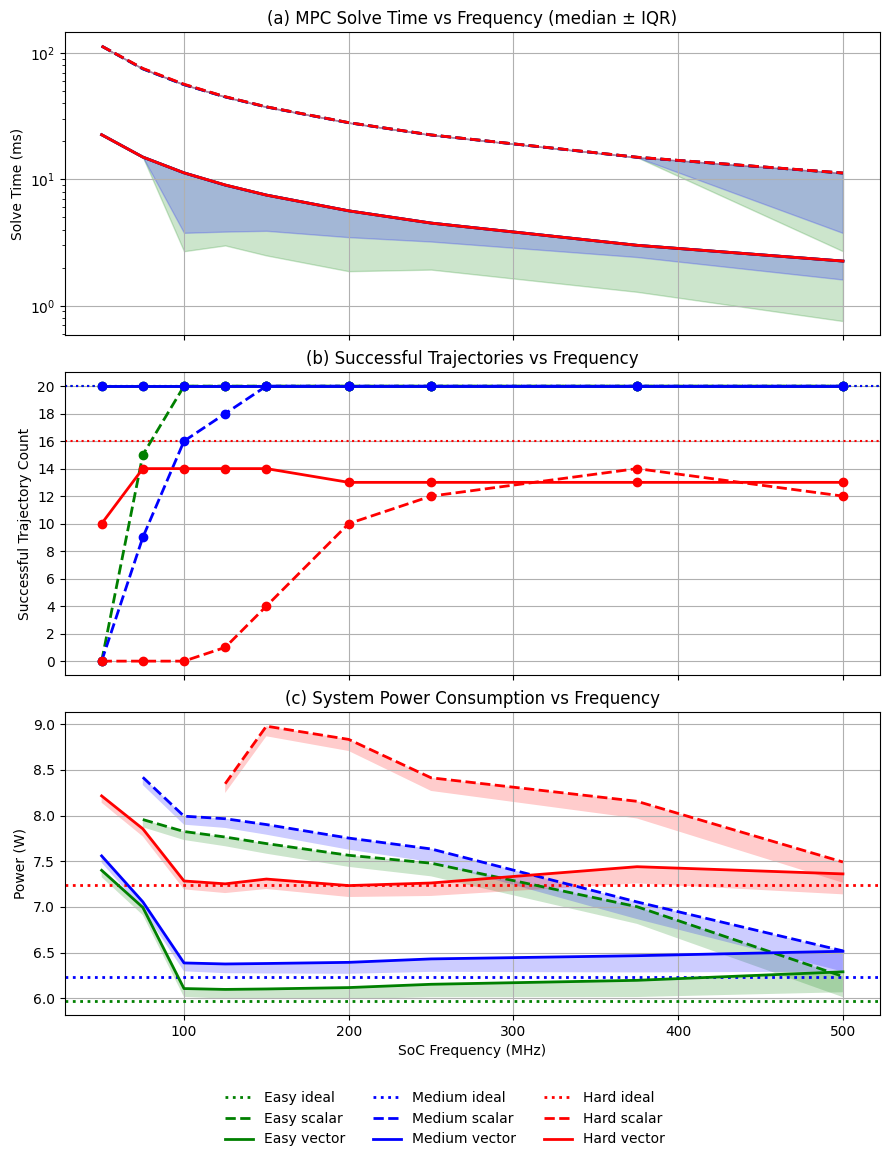

In [283]:
plot_summary(directories, power_data)

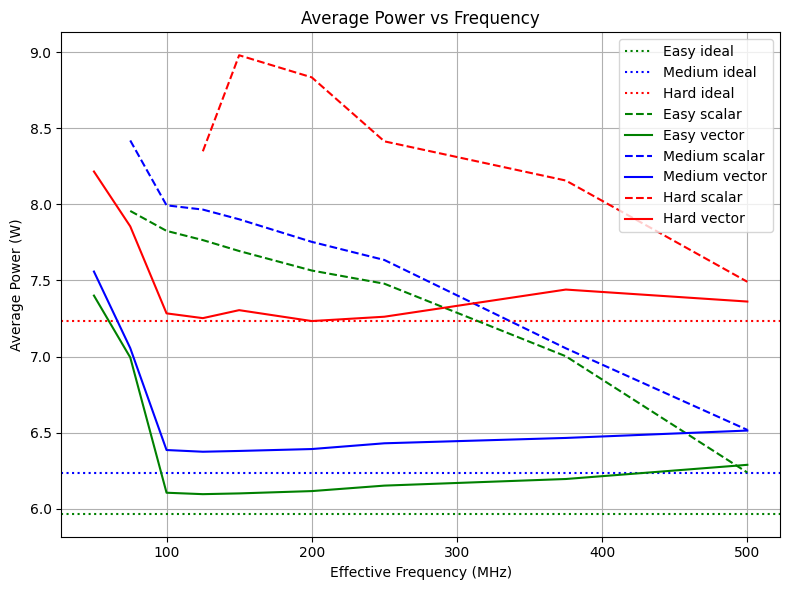

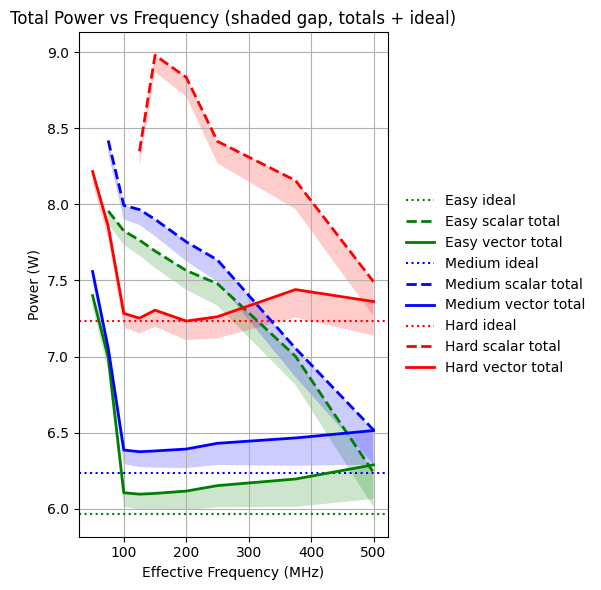

In [209]:
# plot_power_vs_freq(directories)
plot_power_vs_freq(directories, power_data)
plot_power_with_compute_gap(directories, power_data)
# plot_power_bar_chart(directories, power_data)

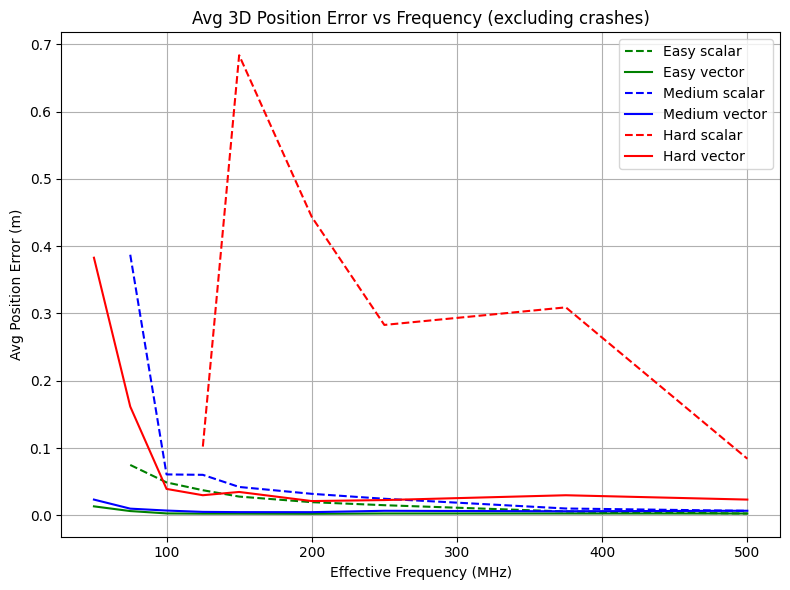

In [206]:
plot_position_error_vs_freq(directories)

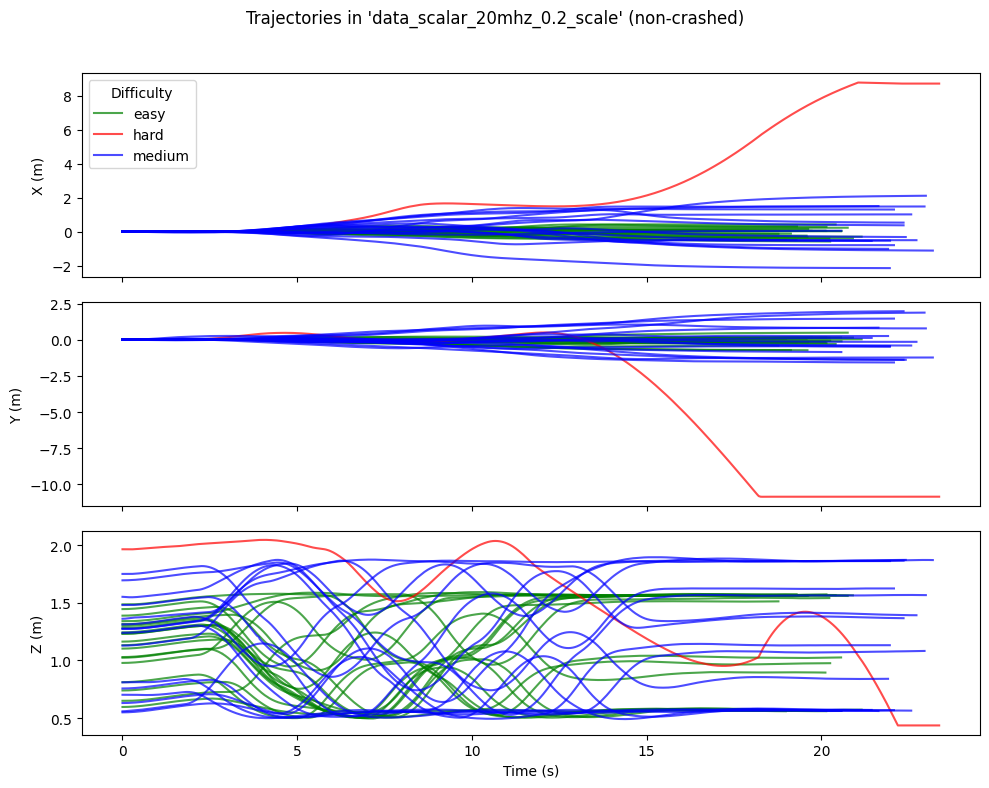

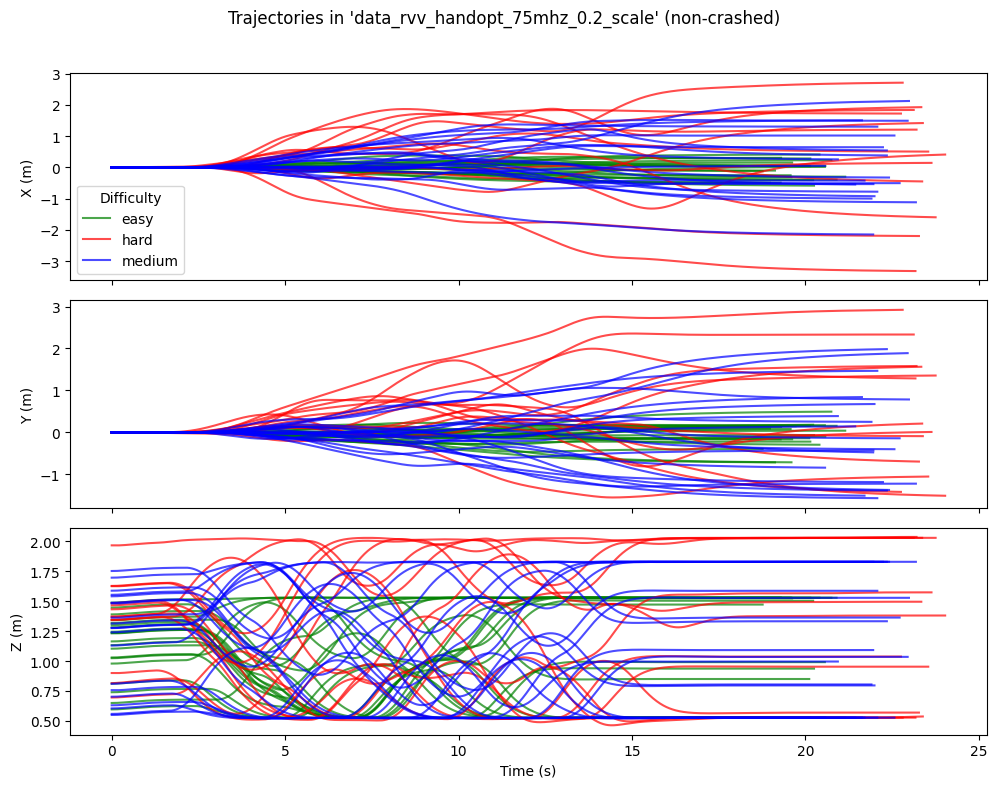

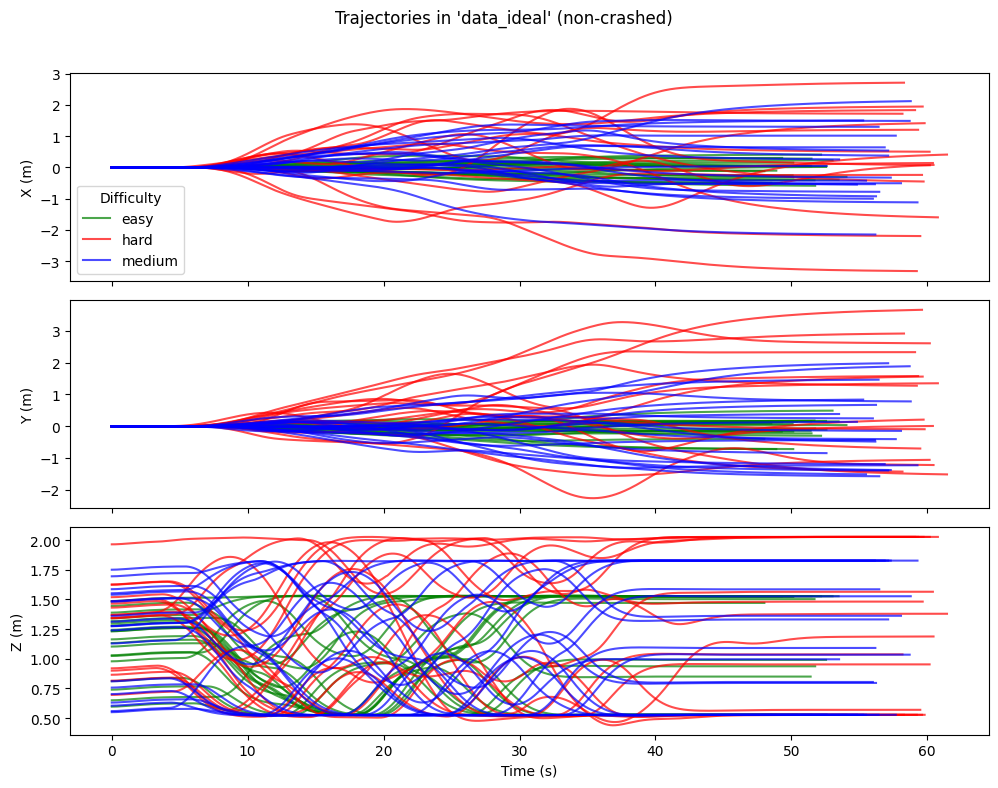

In [181]:
plot_xyz_over_time("data_scalar_20mhz_0.2_scale")
plot_xyz_over_time("data_rvv_handopt_75mhz_0.2_scale")
plot_xyz_over_time("data_ideal")
